In [34]:
import serial
import time
import pyvisa
import sys
import pandas as pd
import matplotlib.pyplot as plt
from decimal import Decimal
from datetime import datetime

################################
#specify capture time in seconds
captureTime = 60
################################

wstitle = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")

csv = open(wstitle + ".csv", "a")


################################
#VISA RESSOURCE MANAGER#
################################
rm = pyvisa.ResourceManager()
#print(rm.list_resources())
DMM = rm.open_resource("TCPIP0::192.168.1.102::inst0::INSTR")


DMM.write("*IDN?")
dmmID = DMM.read()
dmmID = dmmID.replace(",", " ")
dmmID = dmmID.replace("\n", "")

################################
################################

csv.write("Capture Time : " + str(captureTime) + "s," + dmmID + "\n")
csv.write("Timestamp,Current (A) ,Capacity (mAh)\n")

initial_time = time.time()
current_time = initial_time
capacity = 0
i = 0

while(time.time() < initial_time + captureTime):

    DMM.write("READ?")
    DMM_val = float(DMM.read())
    DMM_previous_val = DMM_val

    previous_time = current_time
    current_time = time.time()

    capacity += {True: ( (current_time - previous_time) * DMM_previous_val + (current_time - previous_time) * (DMM_val - DMM_previous_val) / 2) /3.6,
                False: ( (current_time - previous_time) * DMM_val + (current_time - previous_time) * (DMM_previous_val - DMM_val) / 2) / 3.6
                }[DMM_val > DMM_previous_val]

    line_content = str(current_time) + "," + str(DMM_val) + "," + str(capacity)
    line_content = line_content.replace("\n", "")
    csv.write(line_content + "\n")

    i = i + 1
    if(i%100 == 0):
        csv.close()
        csv = open(wstitle + ".csv", "a")
        i = 0
        
csv.close()
DMM.close()

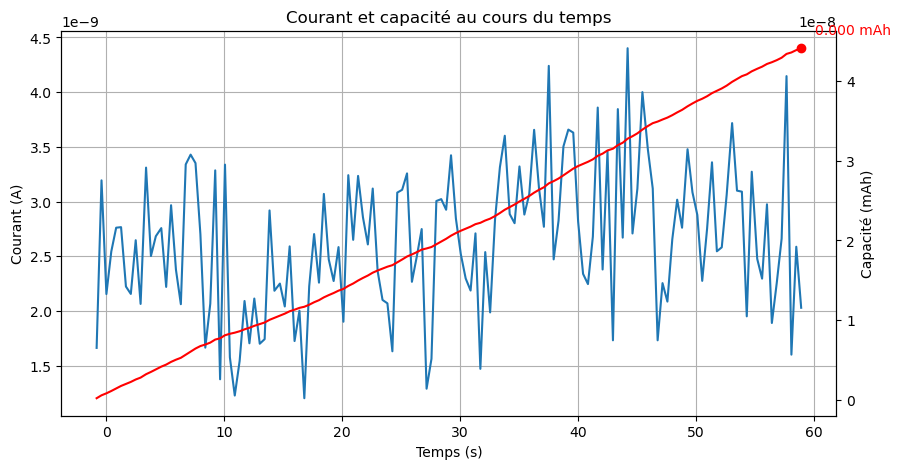

In [42]:
df = pd.read_csv(wstitle + ".csv",
                 header=None, names=["time", "current", "capacity"],
                skiprows = 2)

df["t0"] = df["time"] - df["time"].iloc[2]

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(df["t0"], df["current"], label="Courant (A)")
ax1.set_xlabel("Temps (s)")
ax1.set_ylabel("Courant (A)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(df["t0"], df["capacity"], color='red', label="Capacité (mAh)")

last_t = df["t0"].iloc[-1]
last_cap = df["capacity"].iloc[-1]
ax2.scatter([last_t], [last_cap], color='red')
ax2.annotate(f"{last_cap:.3f} mAh",
             (last_t, last_cap),
             textcoords="offset points",
             xytext=(10,10),
             ha='left',
             color='red')

ax2.set_ylabel("Capacité (mAh)")

plt.title("Courant et capacité au cours du temps")
plt.show()